In [26]:
# Import the pyKasso and numpy packages
import pykasso as pk

import os
import glob
import shutil

import matplotlib.pyplot as plt
import CFPy as cfpy
import flopy as flopy
import flopy.utils.binaryfile as bf
import numpy as np
import pandas as pd
import pastas as ps

init_dir = "C:/Users/MRudolph/Documents/GitHub/CFPy/vlab"
os.chdir(init_dir)

# Define Helper Functions

In [27]:
def position_to_index(x, y):
    """
    Get the modflow (!) based index for a given geo position
    
    Keyword Arguments
    x -- x position, m
    y -- y position, m
    
    Return
    column index, row index
    """
    
    col_idx = np.floor(x / delr) + 1
    row_idx = n_rows - np.floor(y / delc)
    
    return col_idx, row_idx

def store_results(number):
    """
    Create a directory and put the current results there
    
    Keyword Arguments
    number -- identifier of the current iteration, float or int
    
    Return
    -
    """
    
    # define directory where to store the results
    target_dir = os.path.join(path, f"run_{number}")
    
    # make sure the directory does not exist
    if os.path.exists(target_dir):
        raise Exception(f"Directory {target_dir} exists already! Unable to write results")
        
    # create directory
    os.makedirs(target_dir)
    
    # get alle files that will be moved
    files_to_move = glob.glob("NODE*") + glob.glob("TUBE*") \
                    + [f"{modelname}.list", f"{modelname}.hds", f"{modelname}.cbc"] \
                    + [f"network_{number}.png"] \
                    + glob.glob("*.nbr") + glob.glob("*.coc") + glob.glob("*.cfp") + glob.glob("*.crch")
    
    # move files to directory
    for f in files_to_move:
        source = os.path.join(path, f)
        destination = os.path.join(target_dir, f)
        shutil.move(source, destination)

def clean_results():
    """
    Remove all run-dictionaries
    
    Keyword Arguments
    -
    
    Return
    -
    """    
    run_dirs = glob.glob(os.path.join(path, "run_*"))    
    for rd in run_dirs:
        shutil.rmtree(rd)
        
def plot_network(valid_network, number):
    """
    Plot and save valid network array as png
    
    Keyword Arguments
    valid_network -- valid network array
    number -- identifier of the current iteration, float or int
    
    Return
    -
    """
    
    # create a figure 
    fig = plt.figure(figsize=(10, 10))
    
    # plot the array
    im = plt.imshow(valid_network)
    cb = plt.colorbar(im, shrink=0.3)
    
    # set descriptions
    plt.xlabel("Spaltenindex", size=14)
    plt.ylabel("Reihenindex", size =14)
    cb.set_label("Höhe, m", size=14)
    
    # save figure
    plt.savefig(f'network_{number}.png')

# Set up Model

In [28]:
""" create model object """

# change active directory to model directory

path = os.getcwd() + "/"
path = os.path.join(os.getcwd(), "VLAB_03_RUN")

import os
if not os.path.exists(path):
    os.makedirs(path)

os.chdir(path)

# set model name
modelname = "pyKasso_example"

path_to_exe = "C:/WRDAPP/CFPv2.exe"
mf = flopy.modflow.Modflow(modelname, exe_name=path_to_exe)

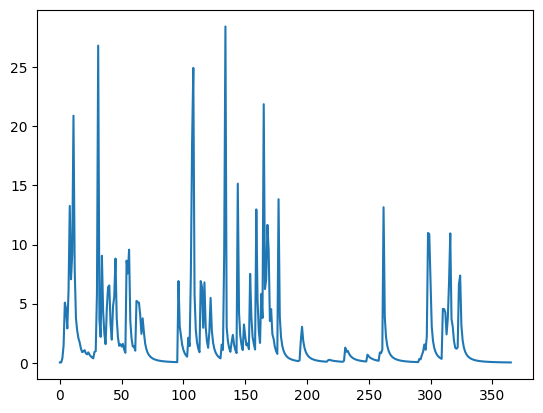

In [29]:
# load prec and evap data
prec = pd.read_csv(
    os.path.join(init_dir, "prec.csv"),
    parse_dates=True,
    index_col=[0],
    sep=";",
    usecols=[0, 2],
    dayfirst=True
).resample("D").sum()

evap = pd.read_csv(
    os.path.join(init_dir, "evap.csv"),
    parse_dates=True,
    index_col=[0],
    sep=";",
    dayfirst=True
)

# pastas flexmodel recharge
rch_ml = ps.recharge.FlexModel(interception=True, snow=False)

# parameters are (always assuming prec and evap to be given in mm/d)
# srmax (root zone storage), [mm]
# lp (fraction at which fraction of sr actual evap becomes potential evap, between 0 and 1), [-]
# ks (sat. hydr. cond.), [mm/d]
# gamma (outflow non-linearity), [-]
# kv (vegetation factor (evap * kv is given to the model)), [-]
# si (interception storage), [mm]

rch_params = [250., 25., 1000., 2., 1., 5.]

n_tiles = 5

prec_ml = np.tile(prec.values.ravel(), n_tiles) # incl warmup
evap_ml = np.tile(evap.values.ravel(), n_tiles) # incl warmup
temp_ml = np.zeros(len(prec))

# simulate
recharge_ts = rch_ml.simulate(
    prec=prec_ml,
    evap=evap_ml,
    temp=temp_ml,  # required positional arg, unused when snow=False
    p=np.array(rch_params)
)

recharge_ts = recharge_ts[len(prec) * (n_tiles - 1):]

fig, ax = plt.subplots()
# ax.plot(prec.index, prec.values)
# ax.plot(evap.index, evap.values)
# ax.plot(prec.index, recharge_ts)

# recharge_ts = recharge_ts[3:8]
ax.plot(recharge_ts)

In [30]:
""" define general domain characteristics """
# NOTE: n_rows, n_cols, n_lays needs to be the same as specified in the .nbr-file!

# number of rows in the domain
n_rows = 50

# number of columns in the domain
n_cols = 100

# number of layers in the domain
n_lays = 1

# width of each cell along rows, m
delr = 50.0

# width of each cell along columns, m
delc = 50.0

# layer elevations [top, bottom], [m, m]
lay_elevs = [50.,0.]


""" hydraulic characteristics """
# horizontal hydraulic conductivity of the porous matrix, m/s
hk = 1E-4

# vertical hydraulic conductivity, m/s
vka = hk


""" time discretization """
# time units: 1=seconds, 2=minutes, 3=hours, 4=days
time_unit = 1

# define number of stress periods
n_pers = len(recharge_ts) + 1 # one steady period at the beginning

# length (number of steps) of stress periods
# this variable assumes a uniform time discretization, i.e. all stress periods
# have the same number of time steps except the first stationary time step
perlen = 86400

# number of time steps in each stress period (integer array)
# e.g., [1, 50, 50, 70, 33, ...]
n_stps = [1] + [1] * (n_pers - 1) # [perlen]

# list with "False" everywhere except 0th element (which is "True")
#     to specify steady state ("True") or transient ("False")
#     stress periods
steady = [1] + [0] * (n_pers - 1) # [1]


""" boundary conditions """
# recharge to WHOLE AREA, mm/a
recharge = 316

# defined head of leftmost column, m
chb_left = 50.0

# defined head at spring node, m
chb_spring = 10.0

# matrix starting head, m
H_init = 75.0


""" solver tolerances """
# modflow general tolerance
mftol = 1e-4

# modflow relaxation parameter
mfrelax = 0.99

# CFP general tolerance
cfptol = 1e-5

# CFP relaxation parameter
cfprelax = 0.99


""" CFP variables """
# pipe diameter, m
diameter = 1.0

# pipe tortuosity
tortuosity = 1.

# roughness height, m
rheight = 0.02

# lower critical reynolds number
lcritrey = 500

# higher critical reynolds number
hcritrey = 5000

# conduit wall conductivity, m^2/s
k_exchange = .1

# conduit associated storage (CADS), m
cad = 0.00

# Define pyKasso Model and Create Network
- notes on pyKasso grid
    - even if we have just one MODFLOW layer, we can discretize the conduit generation process in pyKasso using as many layers as we want
    - although nrow and ncol should match for MODFLOW and pyKasso, the number of layers does not have to match
    - we need to make sure, however, that the overall domain dimensions / elevations do match

In [31]:
# Create a pyKasso application
app = pk.pykasso()

# compute domain thickness for pyKasso
# we assume here that we have just one MODFLOW layer
thickness_pk = lay_elevs[0] - lay_elevs[-1]
nz = 10
dz = thickness_pk / nz

# Declare the grid parameters
grid_parameters = {
    'x0': 0, 'y0': 0, 'z0': 0,
    'nx': n_cols, 'ny': n_rows, 'nz': nz, # ncol, nrow, xxx
    'dx': delr, 'dy': delc, 'dz': thickness_pk / nz,
}

# Declare the project parameters
app.new_project(name='example_02', grid_parameters=grid_parameters)

# Declare some options for the visualization
app.visualizer.notebook = True
extent = app.project.grid.extent
imshow_options = {'extent': extent}

### Notes
- in the documentation / the [example](https://github.com/randlab/pyKasso/blob/master/notebooks/paper/example_02.ipynb), there are information on water table and bedrock that are given to pyKasso
- we don't care for that here, so we use simple placeholders

In [32]:
bedrock = np.zeros((grid_parameters["nx"], grid_parameters["ny"]))

# simple linear interpolation between fixed head on left and spring discharge elevation
# water_table = np.linspace(chb_left, chb_spring, grid_parameters['nx'])
# water_table = np.repeat(water_table[:, np.newaxis], grid_parameters['ny'], axis=1)
water_table = np.full((grid_parameters["nx"], grid_parameters["ny"]), chb_spring)

In [33]:
# Declare the model parameters

# define outlet location
# o_x = (n_cols - 1) * delr
# o_y = (int(n_rows / 2) * delc)
# o_z = chb_spring

# define inlet location
in_x_0 = (n_cols * delr) / 5
in_y_0 = (n_rows * delc) / 5

model_parameters = {
    'sks' : {
        'seed' : 12345,
        'algorithm': "Riemann3",
        'ratio': .1,
    },
    'domain' : {
        'bedrock' : bedrock,
        'water_table' : water_table
    },
    'outlets' : {
        # # [[o_x, o_y, o_z]],
        'seed': 7,
        'number' : 1,
        'subdomain': 'domain_borders_bottom',
    },
    'inlets' : {
        'data' : [
            [in_x_0, in_y_0],
            # [(n_cols * delr) / 4, (n_rows * delc) / 2],
            # [(n_cols * delr) / 3, (n_rows * delc) / 1.5],
            ],
        'number': 1,
        # 'seed': 1,
        # 'number': 3,
    },
    'fractures' : {
        'generate': {
            'family_01': {
                'density'      : 0.000005,
                'orientation'  : [135, 160],
                'dip'          : [90, 160],
                'length'       : [300, 400],
                'alpha'        : 1.5
            },
            'family_02': {
                'density'      : 0.000005,
                'orientation'  : [45, 70],
                'dip'          : [90, 120],
                'length'       : [500, 700],
                'alpha'        : 1.5
            }
        }
    },
}

In [34]:
app.model.generate(model_parameters=model_parameters)

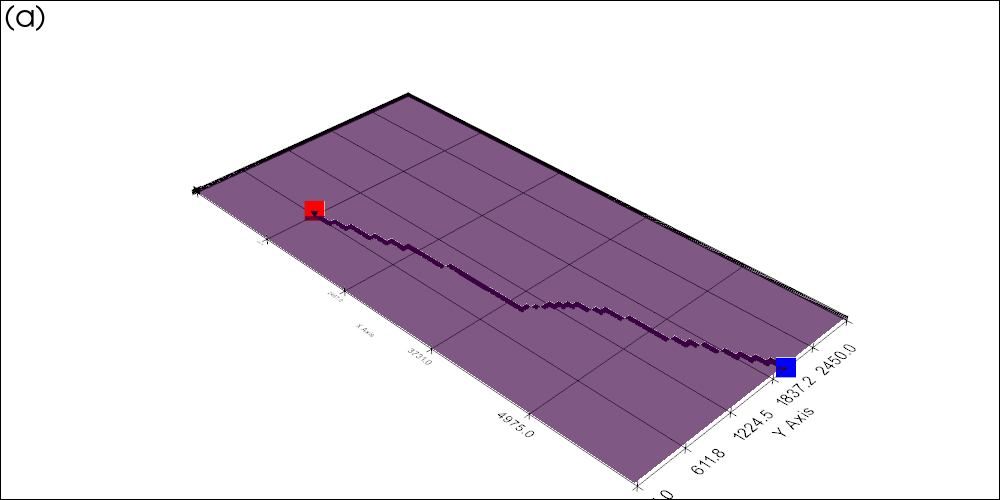

In [35]:
# Basic settings for pv_show() 
settings = {
    'mask_values': [0], # To mask the geology
    'surfaces_options' : { # To see the top bedrock and water level
        # 'bedrock' : {'opacity':1, 'cmap': 'copper'},
        'water_table' : {},
    },
    'inlets_options' : {},
    'outlets_options' : {},
    'show_scalar_bar' : False,
}

# To add the (a) and (b) labels on the subfigures
font_size = 12
settings_1 = settings.copy()
settings_1['text_options'] = {'text' : '(a)', 'font_size': font_size}
settings_2 = settings.copy()
settings_2['text_options'] = {'text' : '(b)', 'font_size': font_size}

# To select the two last simulations
last_simulations = app.project.get_last_simulations(2)

# File name to save the figure
figfilename = os.path.join('fig', 'example_02_iso_vs_ani.png') 

# Generating the 3D plot
app.visualizer.pv_show(
    simulations=last_simulations,
    features=['karst'],
    settings=[settings_1, settings_2],
    cpos=[1, -1, 1],
    window_size=(1000, 500),
    zoom=1.4,
    savefig=False,
    filename=figfilename,
)

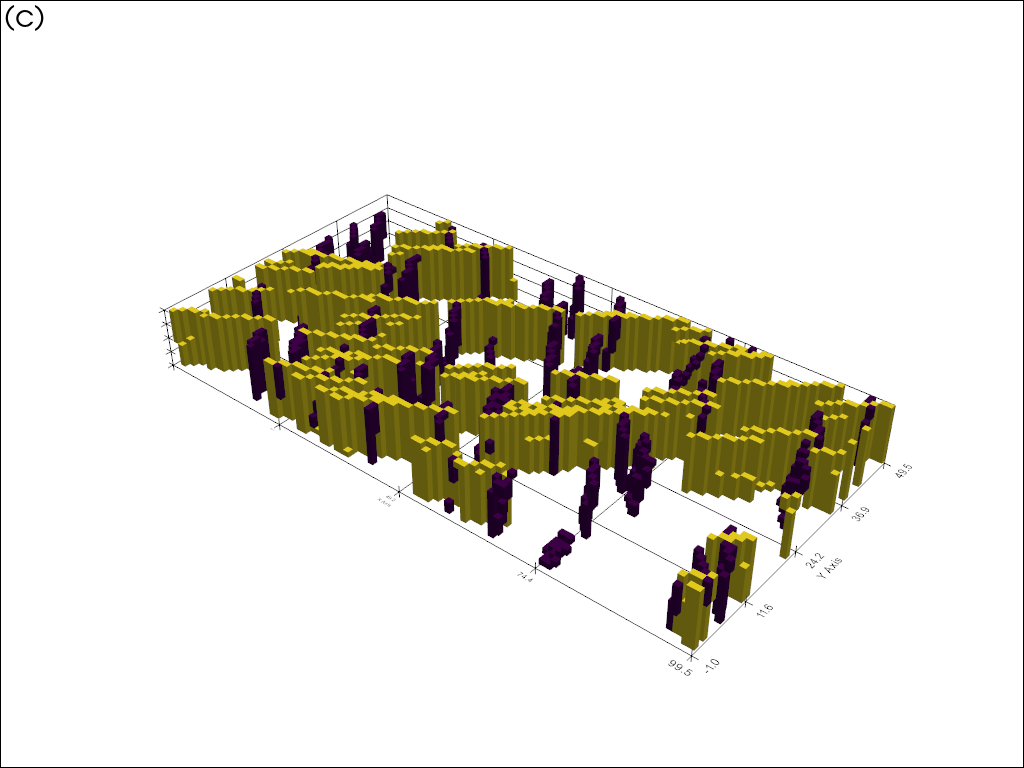

In [36]:
# Plot fracturation
settings = {
    'text_options' : {
        'text': '(c)',
        'font_size': font_size,
    },
    'mask_values': [0],
    'show_scalar_bar': False,
}

cpos = [1,-1.2,1.1]
fig = app.visualizer.pv_plot_array(
    app.model.fractures.data_volume,
    settings=settings,
    cpos=cpos,
    # window_size=window_size,
    # zoom=zoom,
    savefig=False,
    filename=os.path.join('fig','example_03_fracturation_model')
)

In [37]:
# get outlet position
o_x = float(app.model.outlets.x[0])
o_y = float(app.model.outlets.y[0])
o_z = float(app.model.outlets.z[0])

## pyKasso Update / Improvement
- pyKasso can _voxelize_ the karst network
- after that, we get a discrete cell-by-cell network that we can also use in `CFPy`
- we are missing, however, the node elevation data
- we created a small addition in `pyKasso.sks.SKS._voxelize_karst_network`
- now, `SKS` has an attribute `node_elev_arr` that includes the cell-by-cell _voxelized_ node elevations we can directly use for `CFPy`

(100, 50, 10)
(50, 100, 10)
(100, 50, 10)
(50, 100, 10)


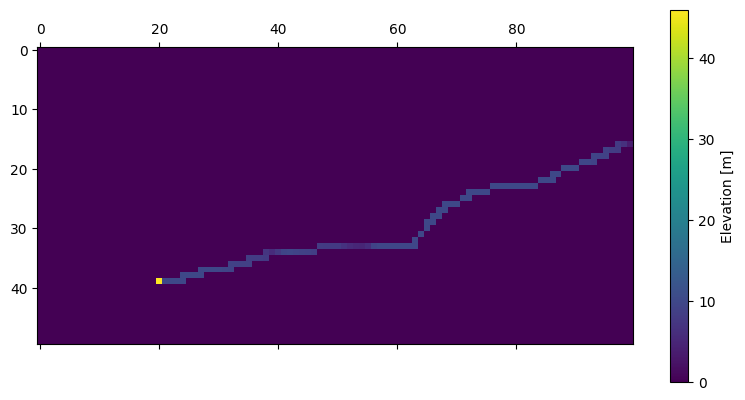

In [38]:
network = np.array(app.model.maps['karst'][0]) # shape (nx, ny, nz) == (ncol, nrow, nlay)
print(network.shape)
network = np.moveaxis(network, 1, 0)
print(network.shape)

elevations = app.model.node_elev_arr
print(elevations.shape)
elevations = np.moveaxis(elevations, 1, 0)
print(elevations.shape)

# "project" the nodes onto the plane
network = np.max(network, axis=-1)[::-1, :]
# perform the same transform with elevs
elevations = np.max(elevations, axis=-1)[::-1, :]

plt.matshow(network * elevations)
plt.colorbar(label="Elevation [m]")


Always visually check the validated network for structuralcorrectness! 
i.e., whether branches are correctly isolated or ifthey got connected during processing.


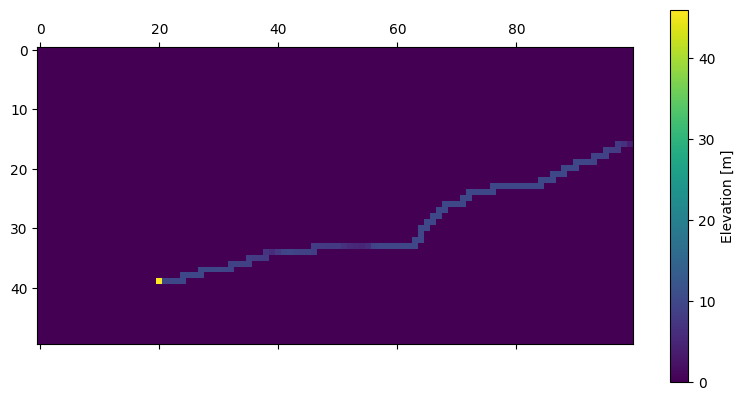

In [39]:
# use a CFPy elevation-enabled validator to validate the network

# validate the network from pyKasso
validator = cfpy.preprocessing.GeneralValidator(network=network, elevations=elevations)
valid_network = validator.validate_network_elevations()

# nrows = catchment.get_ynum()
# ncols = catchment.get_xnum()

# validator.generate_nbr(nrows=nrows, ncols=ncols, nlays=1, layer_elevations=[[1000.], [0.]])

# plot the network
plt.matshow(valid_network)
plt.colorbar(label="Elevation [m]")

# Create MODFLOW Packages

In [40]:
# Get the modflow indices for spring
col_idx_spring, row_idx_spring = position_to_index(o_x, o_y)
idxs_spring = [int(col_idx_spring), int(row_idx_spring), 1]

print(idxs_spring)

# Get the modflow indices for inlet
col_idx_inlet, row_idx_inlet = position_to_index(in_x_0, in_y_0)
idxs_inlet = [int(col_idx_inlet), int(row_idx_inlet), 1]

print(idxs_inlet)

# Compute total length along x
Lx = n_cols*delr
# Compute total length along y
Ly = n_rows*delc

# expand elevations to array
lay_elevs_array = [np.ones((n_rows, n_cols)) * lay_elevs[0],
                   np.ones((n_rows, n_cols)) * lay_elevs[1]]

[100, 17, 1]
[21, 40, 1]


In [41]:
""" DIS """
# Create dis object
dis = flopy.modflow.ModflowDis(mf, n_lays, n_rows, n_cols, n_pers, delr, delc, 
                               top=lay_elevs[0], botm=lay_elevs[1],
                               perlen=perlen, nstp=n_stps, steady=steady,
                               itmuni=time_unit, lenuni=2)

""" BAS6 """
# if ibound < 0: constant head, if = 0: inactive, if > 0: active.
# create arrays to indicate active cells (ibound) and starting heads (H_init)

# integer array of dim (z,y,x), makes all cells active 
ibound = np.ones((n_lays, n_rows, n_cols), dtype=np.int32)

# replace leftmost column with -1 to indicate constant head 
# ibound[:,:,0] = -1

# initialize starting head array
H_init_array = np.ones((n_lays, n_rows, n_cols), dtype=np.float32)
# assign starting head values to all cells
H_init_array[:,:,:] = H_init
# assign constant head value to leftmost column
H_init_array[:,:,0] = chb_left

bas = flopy.modflow.ModflowBas(mf, ibound=ibound, strt=H_init)

""" LPF """
#unit number to save outputs to
ipakcb = 50
#value assigned to dry cells
hdry = 999.
#0=confined, >0 = unconfined/convertible
laytyp = 1
#method of calculating interblock tranmissivity, 0=harmonic mean (default)
layavg = 0
#horizontal anisotropy (ratio of Ky (along cols) to Kx (along rows)
chani = 1
#indicates vka = Kz
layvka = 0
#wetting, 0=inactive, 1=active
laywet = 0

lpf = flopy.modflow.ModflowLpf(mf, laytyp=laytyp, chani=chani, layvka=layvka, laywet=laywet, 
            ipakcb=ipakcb, hdry=hdry, hk=hk, hani=chani, vka=vka, wetdry=laywet)

""" OC """
# create dictionary
# per_dict = {(0,0):['print head', 'save head', 'save budget']}

per_dict = {}
for i in range(n_pers):
    per_dict[(i, 0)] = ["save head", "print budget"]

# create output control file using dictionary
oc = flopy.modflow.ModflowOc(mf, stress_period_data=per_dict)

""" PCG """
#max number of outer iterations
mxiter = 2000
#number of inner iterations
iter1 = 2000
#flag for matrix conditioning method, 1=modified incomplete cholesky
npcond = 1
#flag for active cell surrounded by dry cells. 0=converts to dry, not0=converts only if hcof=0
ihcofadd = 9999
#relaxation parameter with npcond=1
relax = mfrelax
#estimate of upper bound
nbpol = 2
#printout interval
iprpcg = 5
#print flag, 5=?
mutpcg = 0
#damping factor
damppcg = 0.99

pcg = flopy.modflow.ModflowPcg(mf, mxiter=mxiter, iter1=iter1, npcond=npcond, hclose=mftol, rclose=mftol, 
                               relax=relax, nbpol=nbpol, iprpcg=iprpcg, mutpcg=mutpcg, damp=damppcg,
                               ihcofadd=ihcofadd)

""" RCH """
# flag, 1=rech only applied to top layer
nrchop = 1
# if non-zero, cell budget data will be saved
ipakcb = 50

# # recharge from mm/a to m/s
# recharge_si = recharge / (365.25 * 24 * 60 * 60 * 1000)

# # dictionary of recharge fluxes for each stress period
# rech = {0:recharge_si}

rech = {}

rch_mean = np.mean(recharge_ts) / 86400 / 1000
rech[0] = rch_mean

for i in range(n_pers - 1):
    rch_ = recharge_ts[i] / 86400 / 1000 # mm/d --> mm/s --> m/s
    rech[i + 1] = rch_

rch = flopy.modflow.mfrch.ModflowRch(mf, nrchop=nrchop, ipakcb=ipakcb, rech=rech)

In [42]:
clean_results()

os.chdir(path)

In [43]:
mf.write_input()

k_exchange_list = np.linspace(0.001, 1., 10, endpoint=True)

# export the network that has been created before
# the exported information can directly be included in the .nbr-file as input for CFPy
# notes on how to use the generated data with CFPy is given at the end of the notebook
# per default, the network is exported to "CFPy_exported_network_for_NBR.txt" in the active directory
validator.export_network()

""" Generate NBR """
# generate nbr file
validator.generate_nbr(
    path = path,
    nrows = n_rows,
    ncols = n_cols,
    nlays = n_lays,
    nplanes = 1,
    layer_elevations = lay_elevs_array
)

""" Create NBR """
# create nbr object
nbr = cfpy.nbr()

# read model layer/node and conduit layer/node elevations

# bot_elev has shape (n_layers, n_rows, n_cols)
# cond_elev has shape (n_conduit_layers, n_rows, n_cols)
# function looks for an .nbr-file, if none or more than one file is found, an error is raised
# make sure to only have one .nbr-file in the working directory
bot_elev, cond_elev = nbr.nbr_read()

# create nbr data
nbr_data = nbr.nbr(bot_elev, cond_elev)

""" Pipe Flow Parameter """
# diameter
p_diameter = np.ones(len(nbr_data[5])) * diameter
p_diameter = p_diameter.tolist()

# tortuosity
p_tortuosity = np.ones(len(nbr_data[5])) * tortuosity
p_tortuosity = p_tortuosity.tolist()

# roughness height
p_rheight = np.ones(len(nbr_data[5])) * rheight
p_rheight = p_rheight.tolist()

# lower critical reynolds number
p_lcritrey = np.ones(len(nbr_data[5])) * lcritrey
p_lcritrey = p_lcritrey.tolist()

# higher critical reynolds number
p_hcritrey = np.ones(len(nbr_data[5])) * hcritrey
p_hcritrey = p_hcritrey.tolist()

# summarize all data in a 2D-array
pipe_data = [nbr_data[5], p_diameter, p_tortuosity, p_rheight, p_lcritrey, p_hcritrey]

""" Node Heads """
# parametrization for all n nodes
# if head > 0: fixed head
# if head == -1: calculated head
n_head = np.ones((len(nbr_data[0]))) * -1
n_head = n_head.tolist()

# search if the spring exists in the nodes
if idxs_spring in nbr_data[2]:
    # get the position of spring node inside nbr_data
    pos = nbr_data[2].index(idxs_spring)
    # assign the head to spring node
    n_head[pos] = chb_spring
else:
    raise Exception("Cannot find indices of spring in the indices of nodes!")

node_data = [nbr_data[0], n_head]

""" KEX Data """
kex_data = [nbr_data[0],
            np.ones(len(nbr_data[0])) * k_exchange]

""" CADS Data """
cads_data = np.ones((len(nbr_data[0]))) * cad
cads_data = cads_data.tolist()

""" Instantiate CFP """
cfp = cfpy.cfp(mode = 1,
                nnodes = len(nbr_data[0]), 
                npipes = len(nbr_data[5]), 
                nlay = n_lays, 
                nbr_data = nbr_data, 
                geoheight = cond_elev, 
                sa_exchange = 0, 
                epsilon = cfptol,
                niter = 2000, 
                relax = cfprelax, 
                p_nr = 0, 
                cond_data = pipe_data, 
                n_head = node_data, 
                k_exchange = kex_data, 
                ncl = 0, 
                cl = 0, 
                ltemp = 10,
                condl_data = 0,
                cads = cads_data)

# create list of strings
cfp = cfp.cfp()

""" COC """
coc = cfpy.coc(nnodes = len(nbr_data[0]),
                node_numbers = nbr_data[0],
                n_nts = 1,
                npipes = len(nbr_data[5]), 
                pipe_numbers = nbr_data[5],
                t_nts = 1)

coc = coc.coc()

""" CRCH """
# p_crch is list of length (n_nodes) specifying the direct recharge fraction for each node
# initially set p_crch to 0 for all nodes (no direct recharge)
p_crch = np.zeros((len(nbr_data[0]))).tolist()

# search if the spring exists in the nodes
if idxs_inlet in nbr_data[2]:
    # get the position of inlet node inside nbr_data
    pos = nbr_data[2].index(idxs_inlet)
    # assign the head to spring node
    p_crch[pos] = 1.
else:
    raise Exception("Cannot find indices of inlet in the indices of nodes!")

crch = cfpy.crch(iflag_crch = 1, 
                    nper = n_pers, 
                    node_numbers = nbr_data[0], 
                    p_crch = p_crch)

# create list of strings
crch = crch.crch()

""" Write Input """
input_files = cfpy.write_input(modelname = modelname,
                                data_strings = [coc, crch, cfp],
                                file_extensions = ['coc', 'crch', 'cfp'])

# write CFP input files
input_files.write_input()

""" Update nam file """
nam = cfpy.update_nam(modelname = modelname,
                        mode = 1,
                        cfp_unit_num = 52,
                        crch_unit_num = 53,
                        coc_unit_num = 54)

# update existing .nam file
nam.update_nam()

""" Run model """
success, buff = mf.run_model(silent=False)

Elapsed time (.nbr file read): 0.01 s
Elapsed time (write nbr data): 0.02 s
FloPy is using the following executable to run the model: ..\..\..\..\..\..\..\WRDAPP\CFPv2.exe

                                  MODFLOW-2005     
    U.S. GEOLOGICAL SURVEY MODULAR FINITE-DIFFERENCE GROUND-WATER FLOW MODEL
                   Version 1.9.25 06/04/2013 CFPv2 HTM/STM/UMT-LNK/CADS
THIS IS A RESEARCH VERSION OF CFP MODE 1 FOR TEST PURPOSES WITHOUT ANY WARRANTY REGARDING CORRECTNESS
CONTACT: THOMAS.REIMANN@TU-DRESDEN.DE AND BSHOEMAK@USGS.GOV

 Using NAME file: pyKasso_example.nam 
 Run start date and time (yyyy/mm/dd hh:mm:ss): 2026/04/20 18:51:43

 Solving:  Stress period:     1    Time step:     1    Ground-Water Flow Eqn.
 Solving:  Stress period:     2    Time step:     1    Ground-Water Flow Eqn.
 Solving:  Stress period:     3    Time step:     1    Ground-Water Flow Eqn.
 Solving:  Stress period:     4    Time step:     1    Ground-Water Flow Eqn.
 Solving:  Stress period:     5    Time ste

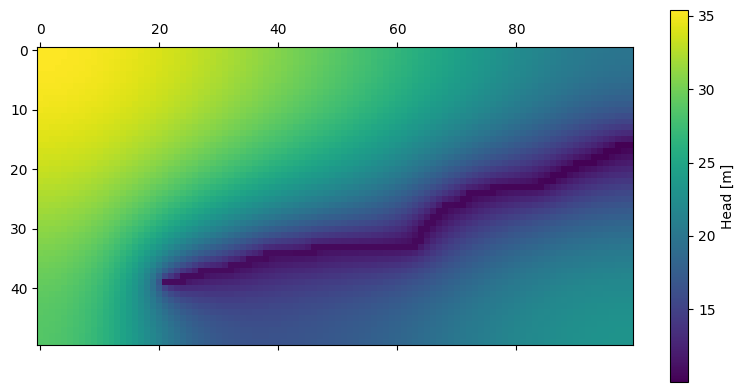

In [44]:
hds_file = os.path.join(path, f"{modelname}.hds")
hds = bf.HeadFile(hds_file)
head = hds.get_alldata()

plt.matshow(head[360, 0, :, :])
plt.colorbar(label="Head [m]")

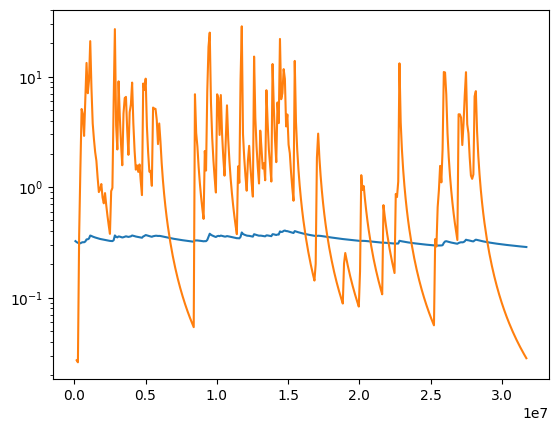

In [47]:
# get conduit flow

flows = pd.read_fwf(
    os.path.join(path, "TUBE00000003.OUT")
)

fig, ax = plt.subplots()
ax.plot(flows[flows.columns[0]], flows[flows.columns[1]])
ax.plot(flows[flows.columns[0]][1:], recharge_ts)
ax.set_yscale("log")